In [1]:
import csv
import json
from pathlib import Path


def json_to_csv(json_path, csv_path=None):
    json_path = Path(json_path)
    csv_path = Path(csv_path) if csv_path is not None else json_path.with_suffix(".csv")

    with json_path.open("r", encoding="utf-8") as file:
        data = json.load(file)

    if isinstance(data, dict):
        data = [data]

    if not isinstance(data, list) or not all(isinstance(row, dict) for row in data):
        raise ValueError("JSON must be an object or a list of objects.")

    fieldnames = []
    seen = set()
    for row in data:
        for key in row.keys():
            if key not in seen:
                seen.add(key)
                fieldnames.append(key)

    with csv_path.open("w", encoding="utf-8", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(data)

    return csv_path


sample_json_path = Path("sample.json")
if not sample_json_path.exists():
    sample_json_path = Path("data/sample.json")

sample_csv_path = json_to_csv(sample_json_path)
sample_csv_path


WindowsPath('sample.csv')

In [2]:
#Load data
import pandas as pd
df = pd.read_csv(sample_csv_path)
df.head(5)

,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,datetime,delta_time
0,1992,323,14,10.872419,106.768248,10.875454,106.758689,1769956638,141.879610
1,1992,323,16,10.872419,106.768248,10.875454,106.758689,1770741962,214.738806
2,1992,323,18,10.872419,106.768248,10.875454,106.758689,1772215611,131.112207
3,1992,323,14,10.872419,106.768248,10.875454,106.758689,1773672421,197.674791
4,1992,323,7,10.872419,106.768248,10.875454,106.758689,1773732442,191.282736


In [3]:
# Convert datetime format from linux timestamp to human-readable format
df_cop = df.copy()
df_cop["timestamp"] = pd.to_datetime(df_cop["datetime"], unit="s")
df_cop.drop(columns=["datetime"], inplace=True)
df_cop.head(5)

#save processed data
output_csv_path = sample_json_path.with_name(sample_json_path.stem + "_processed.csv")
df_cop.to_csv(output_csv_path, index=False)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   stationId              308 non-null    int64  
 1   destination_stationId  308 non-null    int64  
 2   hour                   308 non-null    int64  
 3   lat                    308 non-null    float64
 4   lng                    308 non-null    float64
 5   destination_lat        308 non-null    float64
 6   destination_lng        308 non-null    float64
 7   datetime               308 non-null    int64  
 8   delta_time             308 non-null    float64
dtypes: float64(5), int64(4)
memory usage: 21.8 KB


In [5]:
#time range
print("Time range:", df_cop["timestamp"].min(), "to", df_cop["timestamp"].max())


Time range: 2026-01-01 05:23:27 to 2026-03-30 18:21:39


In [6]:
#from datetime add weekday, month
df_cop["weekday"] = df_cop["timestamp"].dt.weekday
df_cop["month"] = df_cop["timestamp"].dt.month

df_cop.head(5)


,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,delta_time,timestamp,weekday,month
0,1992,323,14,10.872419,106.768248,10.875454,106.758689,141.879610,2026-02-01 14:37:18,6,2
1,1992,323,16,10.872419,106.768248,10.875454,106.758689,214.738806,2026-02-10 16:46:02,1,2
2,1992,323,18,10.872419,106.768248,10.875454,106.758689,131.112207,2026-02-27 18:06:51,4,2
3,1992,323,14,10.872419,106.768248,10.875454,106.758689,197.674791,2026-03-16 14:47:01,0,3
4,1992,323,7,10.872419,106.768248,10.875454,106.758689,191.282736,2026-03-17 07:27:22,1,3


In [7]:
# add `is_weekend`, `is_rush_hour` columns 
df_cop["is_weekend"] = df_cop["weekday"].isin([5, 6]).astype(int)
df_cop["is_rush_hour"] = df_cop["timestamp"].dt.hour.isin([7, 8, 9, 17, 18,19,20]).astype(int)

df_cop.head(5)

,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,delta_time,timestamp,weekday,month,is_weekend,is_rush_hour
0,1992,323,14,10.872419,106.768248,10.875454,106.758689,141.879610,2026-02-01 14:37:18,6,2,1,0
1,1992,323,16,10.872419,106.768248,10.875454,106.758689,214.738806,2026-02-10 16:46:02,1,2,0,0
2,1992,323,18,10.872419,106.768248,10.875454,106.758689,131.112207,2026-02-27 18:06:51,4,2,0,1
3,1992,323,14,10.872419,106.768248,10.875454,106.758689,197.674791,2026-03-16 14:47:01,0,3,0,0
4,1992,323,7,10.872419,106.768248,10.875454,106.758689,191.282736,2026-03-17 07:27:22,1,3,0,1


In [8]:
#date and time split from datetime
df_cop['date'] = df_cop['timestamp'].dt.date
df_cop['time'] = df_cop['timestamp'].dt.time

df_cop.head(5)

#save to csv
output_csv_path = Path("processed_data.csv")
df_cop.to_csv(output_csv_path, index=False)

df_cop.head(5)

,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,delta_time,timestamp,weekday,month,is_weekend,is_rush_hour,date,time
0,1992,323,14,10.872419,106.768248,10.875454,106.758689,141.879610,2026-02-01 14:37:18,6,2,1,0,2026-02-01,14:37:18
1,1992,323,16,10.872419,106.768248,10.875454,106.758689,214.738806,2026-02-10 16:46:02,1,2,0,0,2026-02-10,16:46:02
2,1992,323,18,10.872419,106.768248,10.875454,106.758689,131.112207,2026-02-27 18:06:51,4,2,0,1,2026-02-27,18:06:51
3,1992,323,14,10.872419,106.768248,10.875454,106.758689,197.674791,2026-03-16 14:47:01,0,3,0,0,2026-03-16,14:47:01
4,1992,323,7,10.872419,106.768248,10.875454,106.758689,191.282736,2026-03-17 07:27:22,1,3,0,1,2026-03-17,07:27:22


In [9]:
#weather api: 
# https://archive-api.open-meteo.com/v1/archive?latitude=10.875454,10.872419&longitude=106.758689,106.768248&start_date=2026-01-01&end_date=2026-03-30&hourly=rain&timezone=Asia%2FBangkok

#Load processed data
processed_df = pd.read_csv(output_csv_path)
processed_df.head(5)

,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,delta_time,timestamp,weekday,month,is_weekend,is_rush_hour,date,time
0,1992,323,14,10.872419,106.768248,10.875454,106.758689,141.879610,2026-02-01 14:37:18,6,2,1,0,2026-02-01,14:37:18
1,1992,323,16,10.872419,106.768248,10.875454,106.758689,214.738806,2026-02-10 16:46:02,1,2,0,0,2026-02-10,16:46:02
2,1992,323,18,10.872419,106.768248,10.875454,106.758689,131.112207,2026-02-27 18:06:51,4,2,0,1,2026-02-27,18:06:51
3,1992,323,14,10.872419,106.768248,10.875454,106.758689,197.674791,2026-03-16 14:47:01,0,3,0,0,2026-03-16,14:47:01
4,1992,323,7,10.872419,106.768248,10.875454,106.758689,191.282736,2026-03-17 07:27:22,1,3,0,1,2026-03-17,07:27:22


In [10]:
# add `is_event` column
event_dates = [
    "2026-01-01",  # New Year's Day
    "2026-02-11",  # Lunar New Year
    "2026-02-12",  # Lunar New Year
    "2026-02-13",  # Lunar New Year
    "2026-02-14",  # Lunar New Year
    "2026-02-15",  # Lunar New Year
    "2026-02-16",  # Lunar New Year
    "2026-02-17",  # Lunar New Year
    "2026-02-18",  # Lunar New Year
    "2026-02-19",  # Lunar New Year
    "2026-02-20",  # Lunar New Year
    "2026-02-21",  # Lunar New Year
    "2026-02-22",  # Lunar New Year
    "2026-02-23",  # Lunar New Year
    "2026-02-24",  # Lunar New Year
    "2026-03-08",  #International Women's Day
]

processed_df["is_event"] = processed_df["date"].isin(event_dates).astype(int)
processed_df.head(5)

,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,delta_time,timestamp,weekday,month,is_weekend,is_rush_hour,date,time,is_event
0,1992,323,14,10.872419,106.768248,10.875454,106.758689,141.879610,2026-02-01 14:37:18,6,2,1,0,2026-02-01,14:37:18,0
1,1992,323,16,10.872419,106.768248,10.875454,106.758689,214.738806,2026-02-10 16:46:02,1,2,0,0,2026-02-10,16:46:02,0
2,1992,323,18,10.872419,106.768248,10.875454,106.758689,131.112207,2026-02-27 18:06:51,4,2,0,1,2026-02-27,18:06:51,0
3,1992,323,14,10.872419,106.768248,10.875454,106.758689,197.674791,2026-03-16 14:47:01,0,3,0,0,2026-03-16,14:47:01,0
4,1992,323,7,10.872419,106.768248,10.875454,106.758689,191.282736,2026-03-17 07:27:22,1,3,0,1,2026-03-17,07:27:22,0


In [11]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   stationId              308 non-null    int64  
 1   destination_stationId  308 non-null    int64  
 2   hour                   308 non-null    int64  
 3   lat                    308 non-null    float64
 4   lng                    308 non-null    float64
 5   destination_lat        308 non-null    float64
 6   destination_lng        308 non-null    float64
 7   delta_time             308 non-null    float64
 8   timestamp              308 non-null    object 
 9   weekday                308 non-null    int64  
 10  month                  308 non-null    int64  
 11  is_weekend             308 non-null    int64  
 12  is_rush_hour           308 non-null    int64  
 13  date                   308 non-null    object 
 14  time                   308 non-null    object 
 15  is_eve

# EDA

# Uni

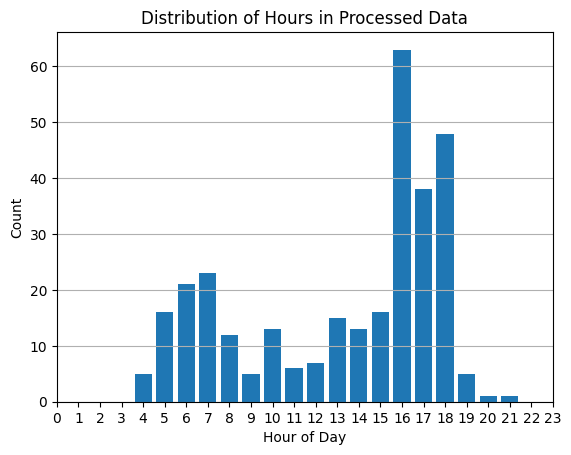

In [12]:
#Hour count distribution
processed_df["hour"] = pd.to_datetime(processed_df["time"], format="%H:%M:%S").dt.hour
hour_counts = processed_df["hour"].value_counts().sort_index()

#visualize hour distribution
import matplotlib.pyplot as plt
plt.bar(hour_counts.index, hour_counts.values)
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.title("Distribution of Hours in Processed Data")
plt.xticks(range(0, 24))
plt.grid(axis="y")
plt.show()

